# Full Graphing Suite

This notebook moves from individual graph types to subplots, a time series, a pie-chart exercise, reusable functions, and a small class. Run each section in order.

The class section is intentionally fully written out. Read the comments and change the example arguments before trying to add new methods yourself.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/materials_qc_raw.csv")

# Remove accidental spaces from column names, such as "Material ".
df.columns = df.columns.str.strip()

# Normalize material labels so equivalent spellings appear as one group.
df["Material Clean"] = (
    df["Material"]
    .str.strip()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

x_column = "Tensile Strength (MPa)"
y_column = "Yield Strength (MPa)"
df[["Material Clean", x_column, y_column]].head()

,Material Clean,Tensile Strength (MPa),Yield Strength (MPa)
0,Aluminum 6061,385.1,300.0
1,Aluminum 6061,273.0,231.1
2,Titanium Ti 6Al 4V,1020.6,872.0
3,Stainless 304,546.1,435.0
4,Stainless 304,619.0,512.7


## 1. One example of each common graph type

- **Scatter plot:** relationship between two numeric measurements.
- **Histogram:** distribution of one numeric measurement.
- **Bar chart:** compare one summary value across categories.
- **Box plot:** compare the distribution of a numeric measurement across categories.

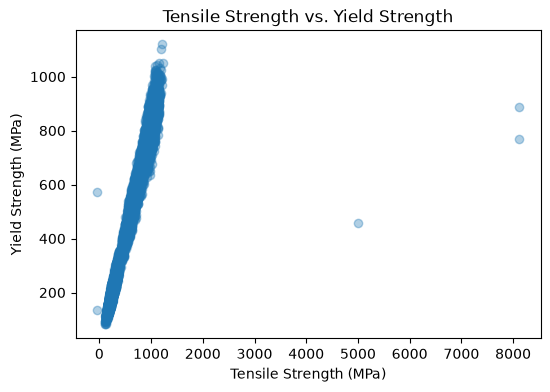

In [2]:
# Scatter: each point is one quality-control record.
plt.figure(figsize=(6, 4))
plt.scatter(df[x_column], df[y_column], alpha=0.35)
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.title("Tensile Strength vs. Yield Strength")
plt.show()

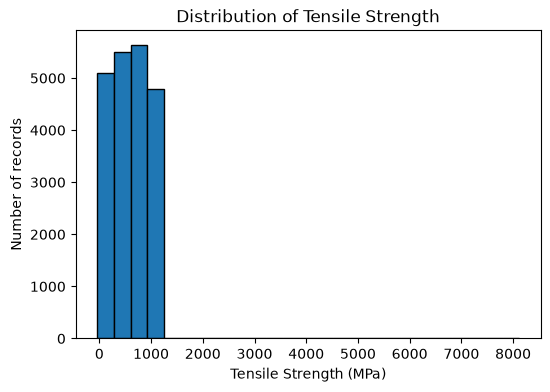

In [3]:
# Histogram: how often each tensile-strength range occurs.
plt.figure(figsize=(6, 4))
plt.hist(df[x_column], bins=25, edgecolor="black")
plt.xlabel(x_column)
plt.ylabel("Number of records")
plt.title("Distribution of Tensile Strength")
plt.show()

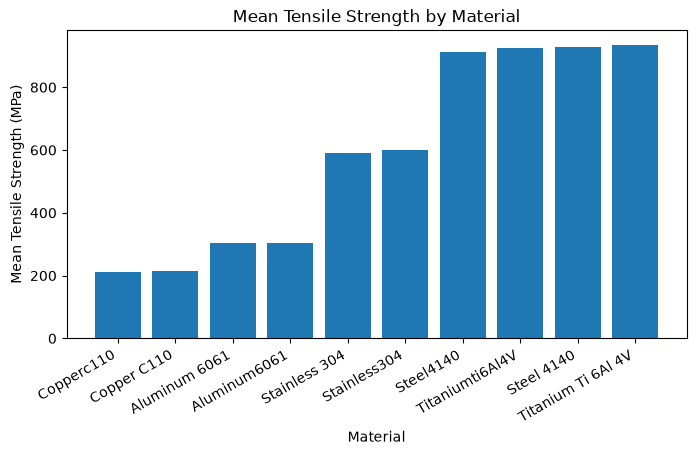

In [4]:
# Bar chart: one mean tensile strength for each material.
mean_tensile_by_material = df.groupby("Material Clean")[x_column].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.bar(mean_tensile_by_material.index, mean_tensile_by_material.values)
plt.xlabel("Material")
plt.ylabel(f"Mean {x_column}")
plt.title("Mean Tensile Strength by Material")
plt.xticks(rotation=30, ha="right")
plt.show()

<Figure size 600x400 with 0 Axes>

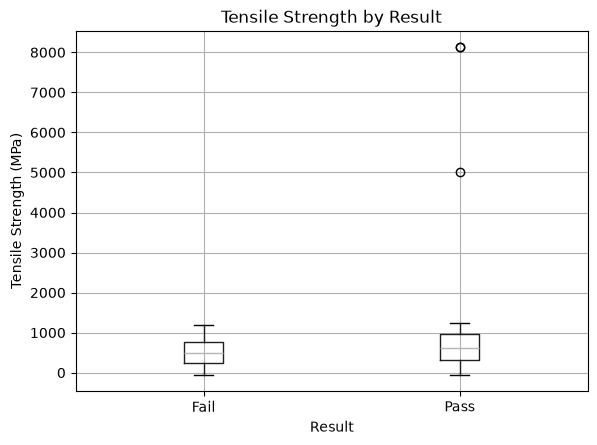

In [5]:
# Box plot: compare tensile-strength distributions by pass/fail result.
plt.figure(figsize=(6, 4))
df.boxplot(column=x_column, by="Pass/Fail")
plt.title("Tensile Strength by Result")
plt.suptitle("")  # Removes pandas' automatic extra title.
plt.xlabel("Result")
plt.ylabel(x_column)
plt.show()

## 2. Put several graph types in one figure

`fig` represents the whole figure. `axes` is a 2-by-2 grid of individual plots. For example, `axes[0, 1]` means row 0, column 1.

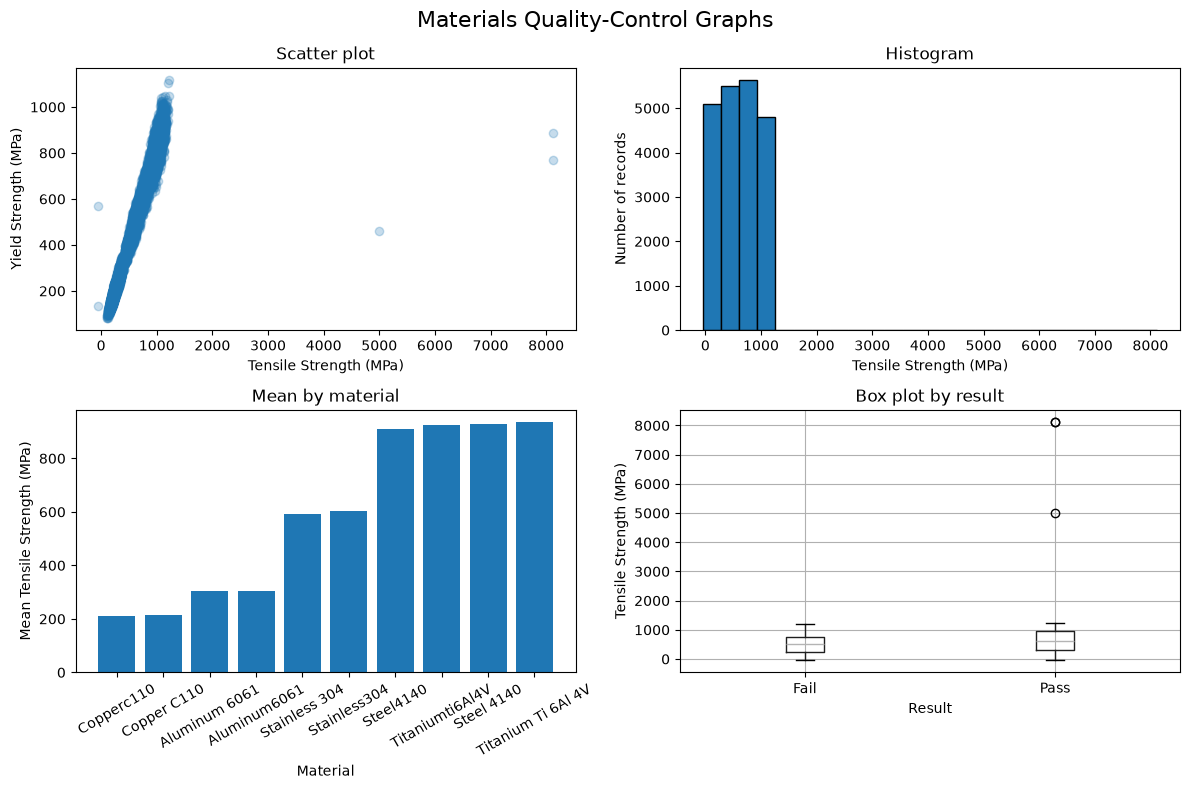

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(df[x_column], df[y_column], alpha=0.25)
axes[0, 0].set(title="Scatter plot", xlabel=x_column, ylabel=y_column)

axes[0, 1].hist(df[x_column], bins=25, edgecolor="black")
axes[0, 1].set(title="Histogram", xlabel=x_column, ylabel="Number of records")

axes[1, 0].bar(mean_tensile_by_material.index, mean_tensile_by_material.values)
axes[1, 0].set(title="Mean by material", xlabel="Material", ylabel=f"Mean {x_column}")
axes[1, 0].tick_params(axis="x", rotation=30)

df.boxplot(column=x_column, by="Pass/Fail", ax=axes[1, 1])
axes[1, 1].set(title="Box plot by result", xlabel="Result", ylabel=x_column)

fig.suptitle("Materials Quality-Control Graphs", fontsize=16)
fig.tight_layout()
plt.show()

## 3. Isolated series graph

A series graph follows one value over an ordered variable. This one follows the **average tensile strength of Steel 4140** across test dates.

122   2022-07-02
139   2022-07-22
140   2022-07-23
141   2022-07-24
192   2022-09-30
193   2022-10-01
270   2023-01-10
307   2023-03-06
308   2023-03-07
326   2023-04-13
411   2023-08-09
561   2024-02-28
562   2024-02-29
563   2024-03-01
Name: Test Date, dtype: datetime64[us]


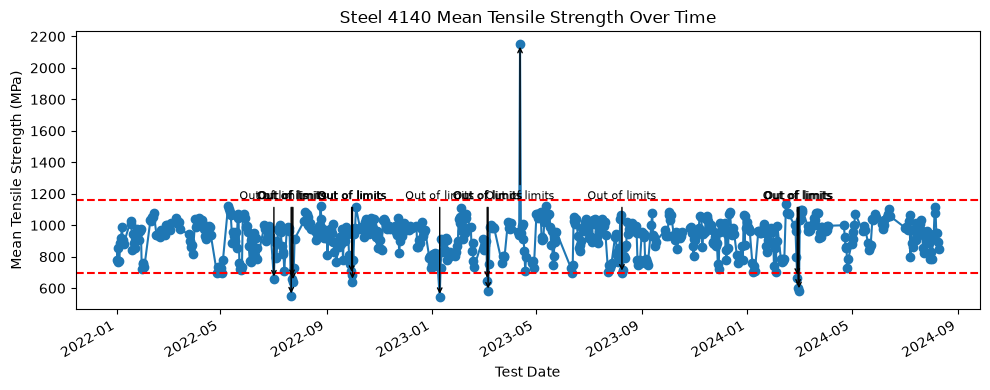

In [10]:
steel_4140 = df.loc[df["Material Clean"] == "Steel 4140", ["Test Date", x_column]].copy()
steel_4140["Test Date"] = pd.to_datetime(steel_4140["Test Date"], format="mixed")

# groupby gives one average measurement per date; sort_values puts dates in order.
steel_4140_by_date = (
    steel_4140.groupby("Test Date", as_index=False)[x_column]
    .mean()
    .sort_values("Test Date")
)

plt.figure(figsize=(10, 4))
plt.plot(steel_4140_by_date["Test Date"], steel_4140_by_date[x_column], marker="o")
plt.xlabel("Test Date")
plt.ylabel(f"Mean {x_column}")
upper_limit = steel_4140_by_date[x_column].mean() + 2 * steel_4140_by_date[x_column].std()
lower_limit = steel_4140_by_date[x_column].mean() - 2 * steel_4140_by_date[x_column].std()
plt.axhline(upper_limit, color="red", linestyle="--", label="Upper Control Limit")
plt.axhline(lower_limit, color="red", linestyle="--", label="Lower Control Limit")
plt.title("Steel 4140 Mean Tensile Strength Over Time")
# generate a list of dates that fall outside limits
out_of_limits_dates = steel_4140_by_date.loc[(steel_4140_by_date[x_column] > upper_limit) | (steel_4140_by_date[x_column] < lower_limit), "Test Date"]
# annotate each out-of-limits date on the plot
for date in out_of_limits_dates:
    plt.annotate(
        "Out of limits",
        xy=(date, steel_4140_by_date.loc[steel_4140_by_date["Test Date"] == date, x_column].values[0]),
        xytext=(date, upper_limit + 5),
        arrowprops=dict(facecolor="black", arrowstyle="->"),
        fontsize=8,
        ha="center",
    )
print(out_of_limits_dates)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Pie-chart fill in the blanks

Complete the three blanks below, then run the cell. Hint: a pandas Series stores its labels in `.index` and its numeric values in `.values`. For percentage labels, Matplotlib accepts a format string such as `"%1.1f%%"`.

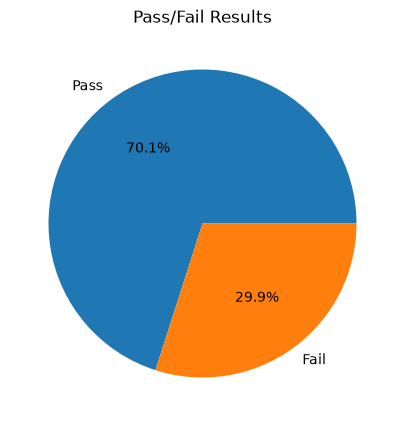

In [11]:
pass_fail_counts = df["Pass/Fail"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [pass_fail_counts["Pass"], pass_fail_counts["Fail"]],        # Fill in: the numeric slice sizes
    labels=pass_fail_counts.index, # Fill in: the slice labels
    autopct="%1.1f%%",            # Fill in: percentage format
)
ax.set_title("Pass/Fail Results")
plt.show()

## 5. Generalize the graphs with functions

A **function** is a named recipe. Instead of rewriting `plt.scatter(...)` for every pair of measurements, give the recipe the DataFrame and column names. The function below returns `ax`, the subplot it drew on, so you can keep customizing it if needed.

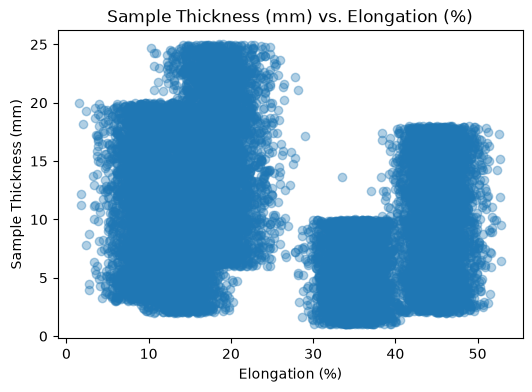

In [12]:
def plot_measurements(data, x_column, y_column, graph_type="scatter", ax=None):
    """Plot any two numeric DataFrame columns on one set of axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    if graph_type == "scatter":
        ax.scatter(data[x_column], data[y_column], alpha=0.35)
    elif graph_type == "line":
        ax.plot(data[x_column], data[y_column])
    else:
        raise ValueError("graph_type must be 'scatter' or 'line'.")

    ax.set(xlabel=x_column, ylabel=y_column, title=f"{y_column} vs. {x_column}")
    return ax


# Change these column names to reuse the same plotting recipe.
plot_measurements(df, "Elongation (%)", "Sample Thickness (mm)")
plt.show()

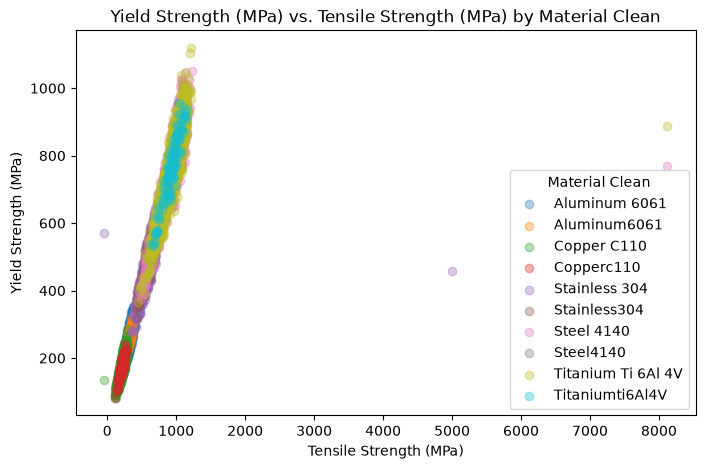

In [13]:
def plot_by_category(data, x_column, y_column, category, ax=None):
    """Draw one scatter series for every value in a category column."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Each loop gives us one category value and only that category's rows.
    for category_value, category_data in data.groupby(category):
        ax.scatter(
            category_data[x_column],
            category_data[y_column],
            alpha=0.35,
            label=category_value,
        )

    ax.set(xlabel=x_column, ylabel=y_column, title=f"{y_column} vs. {x_column} by {category}")
    ax.legend(title=category)
    return ax


plot_by_category(df, x_column, y_column, "Material Clean")
plt.show()

## 6. Generalize with a class

A **class** is a blueprint. `GraphSuite` stores one DataFrame in `self.data`, so you do not have to pass `df` to every method.

An **object** is a usable instance made from that blueprint: `graphs = GraphSuite(df)`. Calling `graphs.scatter(...)` automatically supplies that object's `self.data` to the existing function.

In [ ]:
class GraphSuite:
    """Keep one DataFrame and provide convenient graphing methods for it."""

    def __init__(self, data):
        # `self` means this particular GraphSuite object.
        # Store the provided DataFrame so every method can use it later.
        self.data = data

    def scatter(self, x_column, y_column, ax=None):
        # Reuse the function instead of duplicating its plotting code.
        return plot_measurements(self.data, x_column, y_column, "scatter", ax)

    def scatter_by_category(self, x_column, y_column, category, ax=None):
        return plot_by_category(self.data, x_column, y_column, category, ax)


# 1. Create an object that remembers df.
graphs = GraphSuite(df)

# 2. Call methods on that object. You only provide the column names now.
graphs.scatter("Elongation (%)", "Sample Thickness (mm)")
plt.show()

graphs.scatter_by_category(x_column, y_column, "Material Clean")
plt.show()

## Practice

1. Complete the pie-chart blanks.
2. Change `x_column`, `y_column`, and `category` in the function examples.
3. In `GraphSuite`, add a `histogram(self, column, ax=None)` method. Start by copying the `scatter` method, then replace its body with histogram code.
4. Once that works, add the same histogram to a subplot alongside `graphs.scatter(...)`.